In [2]:
# ============================================================
# PART 1: LOAD & INITIAL EXPLORATION
# Purpose: Load data and understand what we're working with
# ============================================================
import pandas as pd

# Load your data
df = pd.read_csv('/Users/ujjwalbhatta/Desktop/ecommerce-product-success-predictor/data/featured/amazon_electronics_featured.csv') 

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Basic info
print(f"\n📊 Total Records: {len(df):,}")
print(f"📋 Total Features: {len(df.columns)}")

# Check shape
print(f"\n🔢 Dataset Shape: {df.shape}")

# First few rows
print("\n👀 First 3 Rows:")
print(df.head(3))

# Column names
print("\n📝 All Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

# Data types
print("\n🏷️ Data Types:")
print(df.dtypes.value_counts())

# Missing values
print("\n❓ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values!")

print("\n" + "=" * 60)

DATASET OVERVIEW

📊 Total Records: 29,998
📋 Total Features: 38

🔢 Dataset Shape: (29998, 38)

👀 First 3 Rows:
  parent_asin    main_category  \
0  B08FF2X3PV  All Electronics   
1  B086KTM3WQ   Camera & Photo   
2  B00FB50SBU        Computers   

                                       product_title  \
0  canon tr8620 all-in-one printer for home offic...   
1  arenti indoor home security camera 1080p hd 2 ...   
2             amazon basics 14-inch tablet bag black   

                                         description  price  average_rating  \
0  when you need a compact home office printer th...  24.99             4.3   
1                                     no description  42.98             4.2   
2  product description , amazon basics 14-inch ta...  18.30             4.7   

   rating_number          brand          store  \
0           2924          Canon          Canon   
1           2535         Arenti         Arenti   
2          82733  Amazon Basics  Amazon Basics   

          

TARGET VARIABLES ANALYSIS

📊 RATING DISTRIBUTION (Regression Target)
------------------------------------------------------------
Mean Rating: 4.27
Median Rating: 4.40
Std Dev: 0.42
Min Rating: 1.00
Max Rating: 5.00

Rating Distribution:
  1.0 ⭐:    42 (  0.1%) 
  1.1 ⭐:     1 (  0.0%) 
  1.3 ⭐:     2 (  0.0%) 
  1.4 ⭐:     1 (  0.0%) 
  1.5 ⭐:     2 (  0.0%) 
  1.6 ⭐:     2 (  0.0%) 
  1.7 ⭐:     1 (  0.0%) 
  1.9 ⭐:     2 (  0.0%) 
  2.0 ⭐:    17 (  0.1%) 
  2.1 ⭐:     2 (  0.0%) 
  2.2 ⭐:     5 (  0.0%) 
  2.3 ⭐:     6 (  0.0%) 
  2.4 ⭐:     6 (  0.0%) 
  2.5 ⭐:    20 (  0.1%) 
  2.6 ⭐:    14 (  0.0%) 
  2.7 ⭐:    42 (  0.1%) 
  2.8 ⭐:    56 (  0.2%) 
  2.9 ⭐:    75 (  0.3%) 
  3.0 ⭐:   174 (  0.6%) 
  3.1 ⭐:   163 (  0.5%) 
  3.2 ⭐:   236 (  0.8%) 
  3.3 ⭐:   268 (  0.9%) 
  3.4 ⭐:   344 (  1.1%) █
  3.5 ⭐:   409 (  1.4%) █
  3.6 ⭐:   487 (  1.6%) █
  3.7 ⭐:   714 (  2.4%) ██
  3.8 ⭐:   925 (  3.1%) ███
  3.9 ⭐: 1,142 (  3.8%) ███
  4.0 ⭐: 1,668 (  5.6%) █████
  4.1 ⭐: 1,911 (  6.4

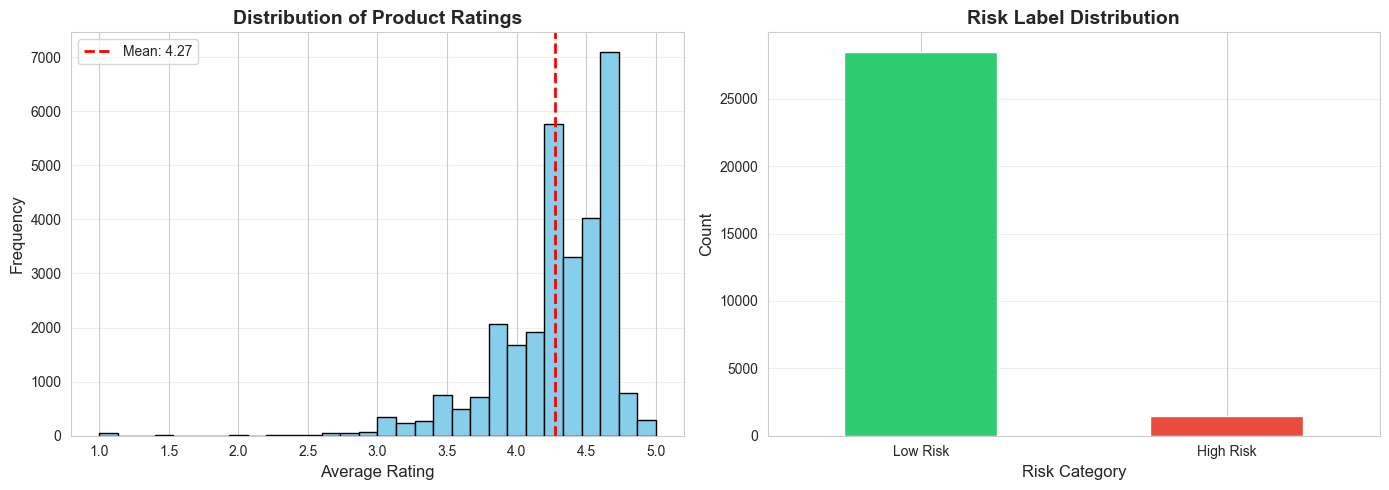

In [3]:
# ============================================================
# PART 2: TARGET VARIABLE ANALYSIS
# Purpose: Understand what we're trying to predict
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("=" * 60)
print("TARGET VARIABLES ANALYSIS")
print("=" * 60)

# ==================== RATING ANALYSIS ====================
print("\n📊 RATING DISTRIBUTION (Regression Target)")
print("-" * 60)

# Statistics
print(f"Mean Rating: {df['average_rating'].mean():.2f}")
print(f"Median Rating: {df['average_rating'].median():.2f}")
print(f"Std Dev: {df['average_rating'].std():.2f}")
print(f"Min Rating: {df['average_rating'].min():.2f}")
print(f"Max Rating: {df['average_rating'].max():.2f}")

# Value counts
print("\nRating Distribution:")
rating_counts = df['average_rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    pct = (count / len(df) * 100)
    bar = "█" * int(pct)
    print(f"  {rating:.1f} ⭐: {count:5,} ({pct:5.1f}%) {bar}")

# ==================== RISK LABEL ANALYSIS ====================
print("\n" + "=" * 60)
print("🚨 RISK LABEL DISTRIBUTION (Classification Target)")
print("-" * 60)

# Value counts
risk_counts = df['risk_label'].value_counts()
print("\nClass Distribution:")
for label, count in risk_counts.items():
    pct = (count / len(df) * 100)
    bar = "█" * int(pct / 2)
    print(f"  {label}: {count:5,} ({pct:5.1f}%) {bar}")

# Check balance
balance_ratio = risk_counts.min() / risk_counts.max()
print(f"\n⚖️ Class Balance Ratio: {balance_ratio:.2f}")
if balance_ratio < 0.3:
    print("⚠️ WARNING: Highly imbalanced! Consider using SMOTE or class weights.")
elif balance_ratio < 0.7:
    print("⚠️ Slightly imbalanced. May need class weights.")
else:
    print("✅ Well balanced!")

# ==================== VISUALIZATIONS ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rating Distribution
axes[0].hist(df['average_rating'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(df['average_rating'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {df["average_rating"].mean():.2f}')
axes[0].set_xlabel('Average Rating', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Product Ratings', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Risk Label Distribution
risk_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Risk Category', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Risk Label Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)

FEATURE ANALYSIS

✅ Found 18 features to use:
   1. log_price
   2. price
   3. brand_tier_encoded
   4. brand_tier_risk_score
   5. is_rare_brand
   6. category_tier_encoded
   7. category_risk_score
   8. category_size_encoded
   9. is_risky_category
  10. is_major_category
  11. log_reviewCount
  12. word_count
  13. sentence_count
  14. sentiment_polarity
  15. sentiment_subjectivity
  16. positive_words
  17. negative_words
  18. quality_ratio

MISSING VALUES IN FEATURES

⚠️ Features with missing values:
  word_count: 40 (0.13%)
  sentence_count: 40 (0.13%)

FEATURE STATISTICS
                             mean         std       min          max
log_price                3.484715    0.858410  0.009950     9.210239
price                   54.758995  132.429540  0.010000  9997.990000
brand_tier_encoded       2.395660    0.998764  0.000000     3.000000
brand_tier_risk_score    4.273138    0.066334  4.233667     4.454448
is_rare_brand            0.699647    0.458419  0.000000     1.0000

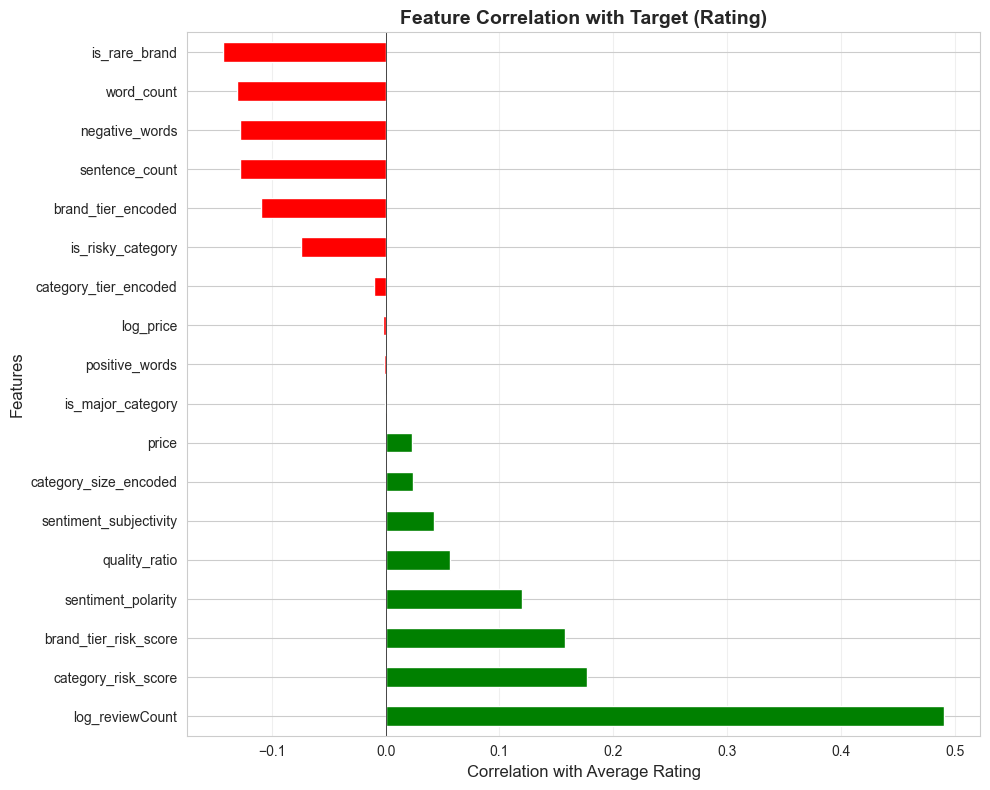

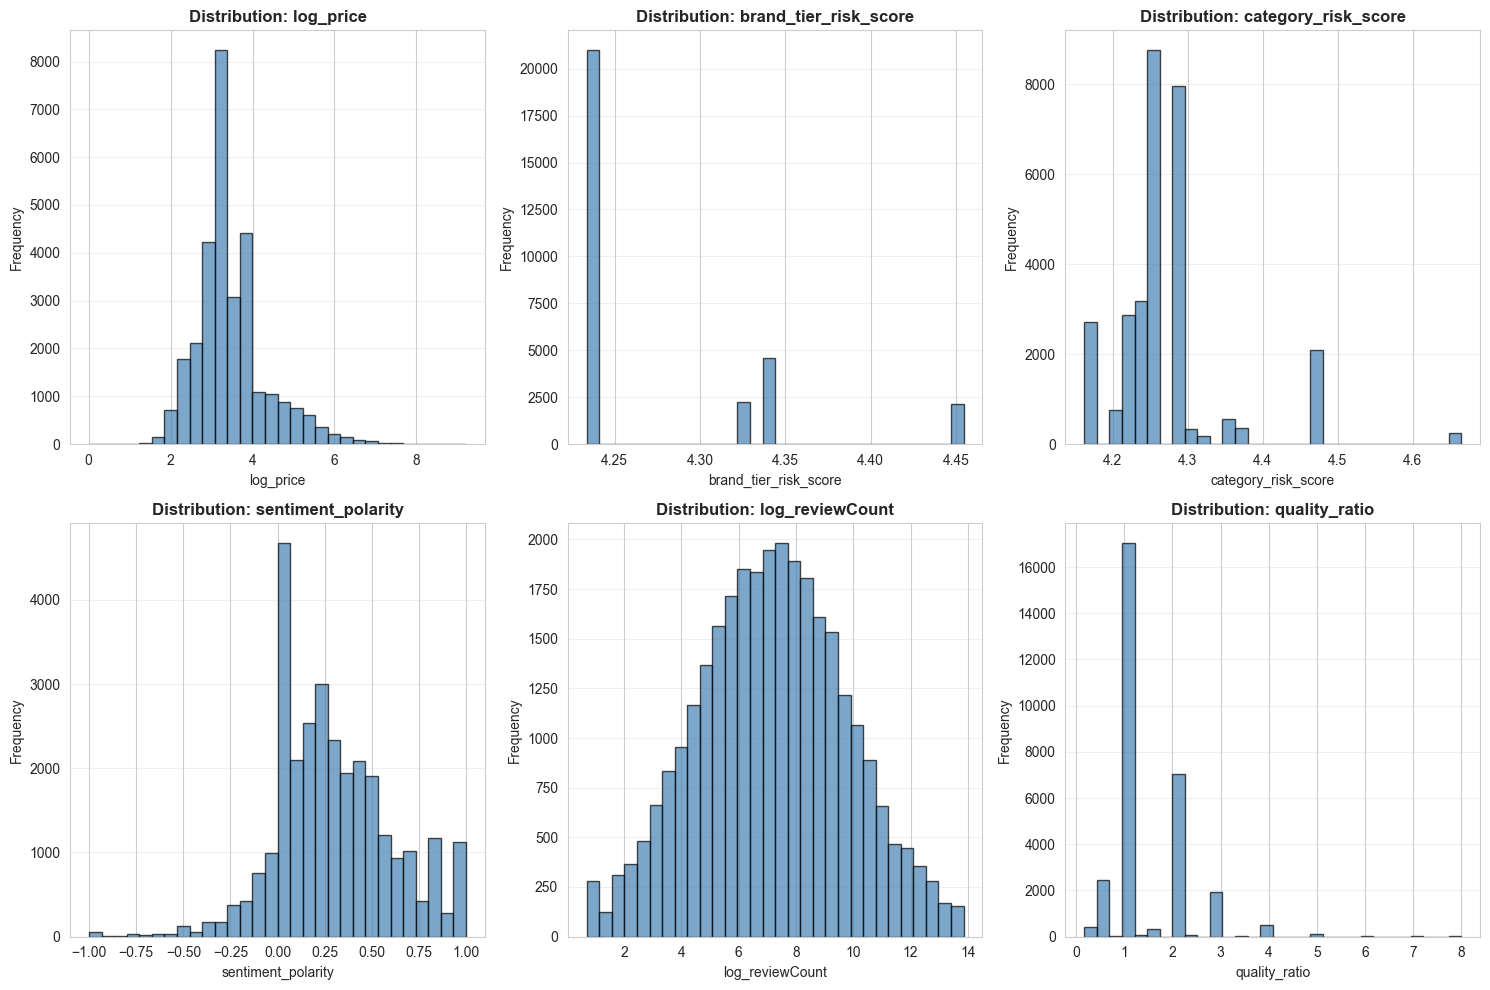


✅ Feature analysis complete!


In [4]:
# ============================================================
# PART 3: FEATURE ANALYSIS
# Purpose: Understand our input features
# ============================================================

import matplotlib.pyplot as plt

print("=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

# Define feature columns (based on your dataset)
feature_columns = [
    # Price features
    'log_price', 
    'price',
    
    # Brand features  
    'brand_tier_encoded',
    'brand_tier_risk_score',
    'is_rare_brand',
    
    # Category features
    'category_tier_encoded', 
    'category_risk_score',
    'category_size_encoded',
    'is_risky_category',
    'is_major_category',
    
    # Engagement features
    'log_reviewCount',
    
    # Text/Quality features
    'word_count',
    'sentence_count', 
    'sentiment_polarity',
    'sentiment_subjectivity',
    'positive_words',
    'negative_words',
    'quality_ratio'
]

# Filter only existing columns
existing_features = [col for col in feature_columns if col in df.columns]
print(f"\n✅ Found {len(existing_features)} features to use:")
for i, feat in enumerate(existing_features, 1):
    print(f"  {i:2}. {feat}")

# Check for missing values in features
print("\n" + "=" * 60)
print("MISSING VALUES IN FEATURES")
print("=" * 60)
missing_in_features = df[existing_features].isnull().sum()
missing_in_features = missing_in_features[missing_in_features > 0]

if len(missing_in_features) > 0:
    print("\n⚠️ Features with missing values:")
    for feat, count in missing_in_features.items():
        pct = (count / len(df) * 100)
        print(f"  {feat}: {count} ({pct:.2f}%)")
else:
    print("\n✅ No missing values in features!")

# Basic statistics
print("\n" + "=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print(df[existing_features].describe().T[['mean', 'std', 'min', 'max']])

# ==================== VISUALIZATIONS ====================

# 1. Correlation with Target (Rating)
print("\n" + "=" * 60)
print("CORRELATION WITH RATING")
print("=" * 60)

correlations = df[existing_features + ['average_rating']].corr()['average_rating'].drop('average_rating').sort_values(ascending=False)
print("\nTop 10 Most Correlated Features:")
print(correlations.head(10))

# Plot correlation
plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.xlabel('Correlation with Average Rating', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Target (Rating)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Distribution of Key Features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

key_features = ['log_price', 'brand_tier_risk_score', 'category_risk_score', 
                'sentiment_polarity', 'log_reviewCount', 'quality_ratio']

for idx, feature in enumerate(key_features[:6]):
    if feature in df.columns:
        axes[idx].hist(df[feature].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution: {feature}', fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ Feature analysis complete!")
print("=" * 60)

In [5]:
# ============================================================
# PART 4: TRAIN/TEST SPLIT
# Purpose: Prepare data for modeling
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("DATA SPLITTING")
print("=" * 60)

# Prepare features and targets
print("\n📦 Preparing data...")

# Features (X)
X = df[existing_features].copy()

# Targets (y)
y_rating = df['average_rating'].copy()  # For regression
y_risk = df['risk_label'].copy()        # For classification

# Handle missing values (simple approach: fill with median/mode)
print("\n🔧 Handling missing values...")
for col in X.columns:
    if X[col].isnull().sum() > 0:
        if X[col].dtype in ['float64', 'int64']:
            X[col].fillna(X[col].median(), inplace=True)
            print(f"  Filled {col} with median")
        else:
            X[col].fillna(X[col].mode()[0], inplace=True)
            print(f"  Filled {col} with mode")

print(f"\n✅ Final feature matrix shape: {X.shape}")
print(f"✅ No missing values: {X.isnull().sum().sum() == 0}")

# Split: 70% train, 15% validation, 15% test
print("\n" + "=" * 60)
print("SPLITTING DATA")
print("=" * 60)

# First split: 70% train, 30% temp
X_train, X_temp, y_rating_train, y_rating_temp, y_risk_train, y_risk_temp = train_test_split(
    X, y_rating, y_risk, 
    test_size=0.3, 
    random_state=42,
    stratify=y_risk  # Ensure balanced risk distribution
)

# Second split: 15% validation, 15% test (50-50 of the 30%)
X_val, X_test, y_rating_val, y_rating_test, y_risk_val, y_risk_test = train_test_split(
    X_temp, y_rating_temp, y_risk_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_risk_temp
)

# Display split info
print("\n📊 Split Sizes:")
print(f"  Training:   {len(X_train):5,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):5,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):5,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total:      {len(X):5,} samples")

# Check class distribution in each split
print("\n🚨 Risk Label Distribution:")
print("\nTraining Set:")
print(y_risk_train.value_counts())
print(f"  Ratio: {y_risk_train.value_counts().min() / y_risk_train.value_counts().max():.2f}")

print("\nValidation Set:")
print(y_risk_val.value_counts())
print(f"  Ratio: {y_risk_val.value_counts().min() / y_risk_val.value_counts().max():.2f}")

print("\nTest Set:")
print(y_risk_test.value_counts())
print(f"  Ratio: {y_risk_test.value_counts().min() / y_risk_test.value_counts().max():.2f}")

# Check rating distribution
print("\n⭐ Rating Distribution:")
print(f"\nTraining Set - Mean: {y_rating_train.mean():.2f}, Std: {y_rating_train.std():.2f}")
print(f"Validation Set - Mean: {y_rating_val.mean():.2f}, Std: {y_rating_val.std():.2f}")
print(f"Test Set - Mean: {y_rating_test.mean():.2f}, Std: {y_rating_test.std():.2f}")

print("\n" + "=" * 60)
print("✅ Data splitting complete!")
print("=" * 60)
print("\n💡 You now have:")
print("  • X_train, X_val, X_test (features)")
print("  • y_rating_train, y_rating_val, y_rating_test (regression targets)")
print("  • y_risk_train, y_risk_val, y_risk_test (classification targets)")

DATA SPLITTING

📦 Preparing data...

🔧 Handling missing values...
  Filled word_count with median
  Filled sentence_count with median

✅ Final feature matrix shape: (29998, 18)
✅ No missing values: True

SPLITTING DATA

📊 Split Sizes:
  Training:   20,998 samples (70.0%)
  Validation: 4,500 samples (15.0%)
  Test:       4,500 samples (15.0%)
  Total:      29,998 samples

🚨 Risk Label Distribution:

Training Set:
risk_label
Low Risk     19961
High Risk     1037
Name: count, dtype: int64
  Ratio: 0.05

Validation Set:
risk_label
Low Risk     4278
High Risk     222
Name: count, dtype: int64
  Ratio: 0.05

Test Set:
risk_label
Low Risk     4278
High Risk     222
Name: count, dtype: int64
  Ratio: 0.05

⭐ Rating Distribution:

Training Set - Mean: 4.27, Std: 0.42
Validation Set - Mean: 4.27, Std: 0.42
Test Set - Mean: 4.27, Std: 0.42

✅ Data splitting complete!

💡 You now have:
  • X_train, X_val, X_test (features)
  • y_rating_train, y_rating_val, y_rating_test (regression targets)
  • y_r

/var/folders/l7/fjgcny815qj4hnytpzftpbsc0000gn/T/ipykernel_44302/2218445198.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


BASELINE MODEL: RATING PREDICTION (REGRESSION)

🔧 Creating Linear Regression model...
📚 Training on training data...
✅ Training complete!

🔮 Making predictions...

MODEL PERFORMANCE

📚 TRAINING SET:
  RMSE (Root Mean Squared Error): 0.3592 ⭐
  MAE (Mean Absolute Error):      0.2584 ⭐
  R² Score:                        0.2765
  📊 Excellent! Predictions within ±0.36 stars on average

🔍 VALIDATION SET:
  RMSE (Root Mean Squared Error): 0.3608 ⭐
  MAE (Mean Absolute Error):      0.2607 ⭐
  R² Score:                        0.2603
  📊 Excellent! Predictions within ±0.36 stars on average

🧪 TEST SET:
  RMSE (Root Mean Squared Error): 0.3620 ⭐
  MAE (Mean Absolute Error):      0.2617 ⭐
  R² Score:                        0.2654
  📊 Excellent! Predictions within ±0.36 stars on average

OVERFITTING CHECK
✅ No overfitting detected! Model generalizes well.
   Difference: -0.0028


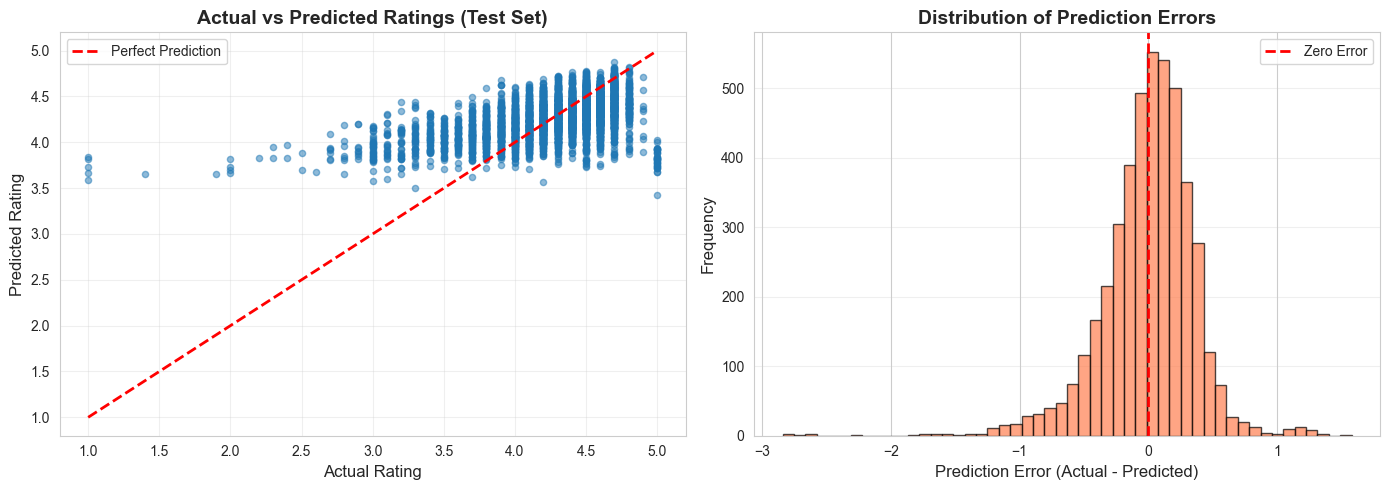


TOP 10 MOST IMPORTANT FEATURES

(Larger absolute value = more influence on rating)
               Feature  Coefficient
 brand_tier_risk_score    -0.458472
     is_risky_category    -0.122304
    sentiment_polarity     0.109178
       log_reviewCount     0.082972
   category_risk_score    -0.074455
        negative_words    -0.054023
sentiment_subjectivity    -0.032287
    brand_tier_encoded    -0.027780
 category_size_encoded     0.026348
         is_rare_brand     0.021755

✅ Baseline regression model complete!


In [6]:
# ============================================================
# PART 5: BASELINE REGRESSION MODEL (Rating Prediction)
# Purpose: Build simple Linear Regression model
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("BASELINE MODEL: RATING PREDICTION (REGRESSION)")
print("=" * 60)

# Initialize model
print("\n🔧 Creating Linear Regression model...")
lr_model = LinearRegression()

# Train model
print("📚 Training on training data...")
lr_model.fit(X_train, y_rating_train)
print("✅ Training complete!")

# Make predictions
print("\n🔮 Making predictions...")
y_pred_train = lr_model.predict(X_train)
y_pred_val = lr_model.predict(X_val)
y_pred_test = lr_model.predict(X_test)

# Calculate metrics
print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

def evaluate_regression(y_true, y_pred, set_name):
    """Calculate and display regression metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name}:")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f} ⭐")
    print(f"  MAE (Mean Absolute Error):      {mae:.4f} ⭐")
    print(f"  R² Score:                        {r2:.4f}")
    
    # Interpretation
    if rmse < 0.5:
        print(f"  📊 Excellent! Predictions within ±{rmse:.2f} stars on average")
    elif rmse < 0.8:
        print(f"  📊 Good! Predictions within ±{rmse:.2f} stars on average")
    else:
        print(f"  📊 Room for improvement. Predictions ±{rmse:.2f} stars off")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate on all sets
train_metrics = evaluate_regression(y_rating_train, y_pred_train, "📚 TRAINING SET")
val_metrics = evaluate_regression(y_rating_val, y_pred_val, "🔍 VALIDATION SET")
test_metrics = evaluate_regression(y_rating_test, y_pred_test, "🧪 TEST SET")

# Check for overfitting
print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)
diff = train_metrics['RMSE'] - test_metrics['RMSE']
if abs(diff) < 0.1:
    print("✅ No overfitting detected! Model generalizes well.")
elif abs(diff) < 0.3:
    print("⚠️ Slight overfitting. Consider regularization.")
else:
    print("🚨 Significant overfitting! Model memorizing training data.")
print(f"   Difference: {diff:.4f}")

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_rating_test, y_pred_test, alpha=0.5, s=20)
axes[0].plot([y_rating_test.min(), y_rating_test.max()], 
             [y_rating_test.min(), y_rating_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating', fontsize=12)
axes[0].set_ylabel('Predicted Rating', fontsize=12)
axes[0].set_title('Actual vs Predicted Ratings (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Prediction Error Distribution
errors = y_rating_test - y_pred_test
axes[1].hist(errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (coefficients)
print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\n(Larger absolute value = more influence on rating)")
print(feature_importance[['Feature', 'Coefficient']].head(10).to_string(index=False))

print("\n" + "=" * 60)
print("✅ Baseline regression model complete!")
print("=" * 60)

#https://www.youtube.com/watch?v=bMccdk8EdGo

ADVANCED REGRESSION MODELS

1️⃣ RANDOM FOREST

🌲 Training Random Forest...
✅ Training complete! Time: 1.05s

📊 Test Set Performance:
  RMSE: 0.3427
  MAE:  0.2355
  R²:   0.3416

2️⃣ XGBOOST

🚀 Training XGBoost...
✅ Training complete! Time: 0.10s

📊 Test Set Performance:
  RMSE: 0.3459
  MAE:  0.2386
  R²:   0.3294

3️⃣ LIGHTGBM

⚡ Training LightGBM...
✅ Training complete! Time: 0.08s

📊 Test Set Performance:
  RMSE: 0.3398
  MAE:  0.2387
  R²:   0.3529

MODEL COMPARISON


        Model     RMSE      MAE       R2     Time
Random Forest 0.342738 0.235534 0.341589 1.053636
      XGBoost 0.345904 0.238646 0.329369 0.100839
     LightGBM 0.339781 0.238654 0.352902 0.076810

🏆 Best Model: LightGBM
   RMSE: 0.3398


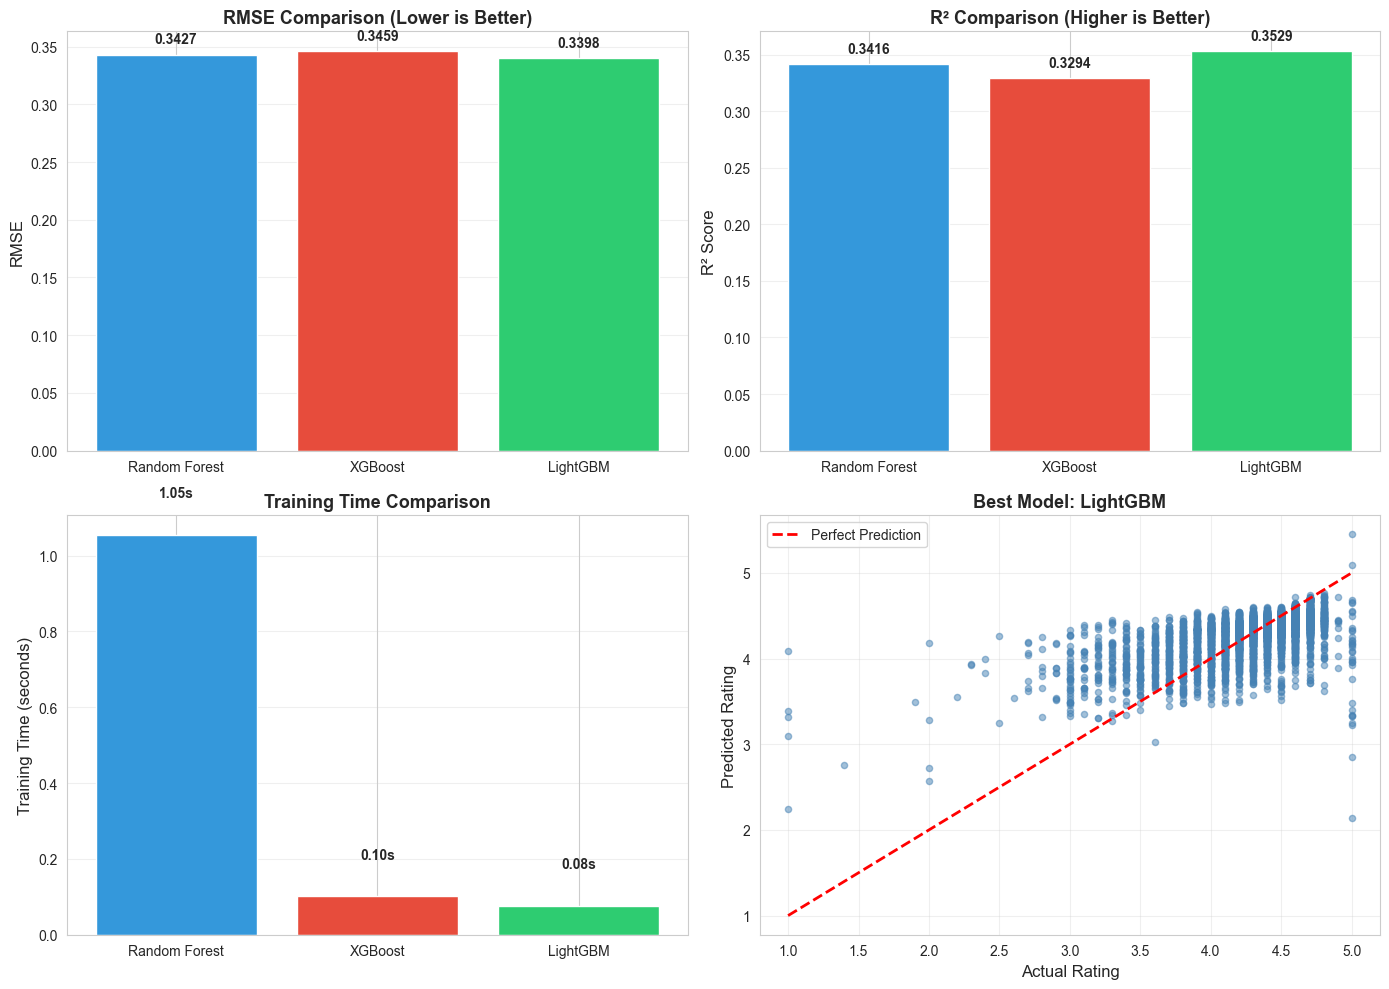


✅ Advanced regression models complete!


In [7]:
# ============================================================
# PART 7: ADVANCED REGRESSION MODELS
# Purpose: Compare Random Forest, XGBoost, LightGBM
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("=" * 60)
print("ADVANCED REGRESSION MODELS")
print("=" * 60)

# Store results
results = []

# ==================== RANDOM FOREST ====================
print("\n" + "=" * 60)
print("1️⃣ RANDOM FOREST")
print("=" * 60)

print("\n🌲 Training Random Forest...")
start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_rating_train)
rf_time = time.time() - start_time

print(f"✅ Training complete! Time: {rf_time:.2f}s")

# Predictions
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_val = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_rating_test, y_pred_rf_test))
rf_mae = mean_absolute_error(y_rating_test, y_pred_rf_test)
rf_r2 = r2_score(y_rating_test, y_pred_rf_test)

print(f"\n📊 Test Set Performance:")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE:  {rf_mae:.4f}")
print(f"  R²:   {rf_r2:.4f}")

results.append({
    'Model': 'Random Forest',
    'RMSE': rf_rmse,
    'MAE': rf_mae,
    'R2': rf_r2,
    'Time': rf_time
})

# ==================== XGBOOST ====================
print("\n" + "=" * 60)
print("2️⃣ XGBOOST")
print("=" * 60)

print("\n🚀 Training XGBoost...")
start_time = time.time()

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_rating_train)
xgb_time = time.time() - start_time

print(f"✅ Training complete! Time: {xgb_time:.2f}s")

# Predictions
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_val = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

# Metrics
xgb_rmse = np.sqrt(mean_squared_error(y_rating_test, y_pred_xgb_test))
xgb_mae = mean_absolute_error(y_rating_test, y_pred_xgb_test)
xgb_r2 = r2_score(y_rating_test, y_pred_xgb_test)

print(f"\n📊 Test Set Performance:")
print(f"  RMSE: {xgb_rmse:.4f}")
print(f"  MAE:  {xgb_mae:.4f}")
print(f"  R²:   {xgb_r2:.4f}")

results.append({
    'Model': 'XGBoost',
    'RMSE': xgb_rmse,
    'MAE': xgb_mae,
    'R2': xgb_r2,
    'Time': xgb_time
})

# ==================== LIGHTGBM ====================
print("\n" + "=" * 60)
print("3️⃣ LIGHTGBM")
print("=" * 60)

print("\n⚡ Training LightGBM...")
start_time = time.time()

lgb_model = LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_rating_train)
lgb_time = time.time() - start_time

print(f"✅ Training complete! Time: {lgb_time:.2f}s")

# Predictions
y_pred_lgb_train = lgb_model.predict(X_train)
y_pred_lgb_val = lgb_model.predict(X_val)
y_pred_lgb_test = lgb_model.predict(X_test)

# Metrics
lgb_rmse = np.sqrt(mean_squared_error(y_rating_test, y_pred_lgb_test))
lgb_mae = mean_absolute_error(y_rating_test, y_pred_lgb_test)
lgb_r2 = r2_score(y_rating_test, y_pred_lgb_test)

print(f"\n📊 Test Set Performance:")
print(f"  RMSE: {lgb_rmse:.4f}")
print(f"  MAE:  {lgb_mae:.4f}")
print(f"  R²:   {lgb_r2:.4f}")

results.append({
    'Model': 'LightGBM',
    'RMSE': lgb_rmse,
    'MAE': lgb_mae,
    'R2': lgb_r2,
    'Time': lgb_time
})

# ==================== COMPARISON ====================
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results)
print("\n")
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['RMSE'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}")

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: RMSE Comparison
axes[0, 0].bar(results_df['Model'], results_df['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_ylabel('RMSE', fontsize=12)
axes[0, 0].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['RMSE']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: R² Comparison
axes[0, 1].bar(results_df['Model'], results_df['R2'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('R² Comparison (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['R2']):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 3: Training Time
axes[1, 0].bar(results_df['Model'], results_df['Time'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 0].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1, 0].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Time']):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')

# Plot 4: Actual vs Predicted (Best Model)
if best_model_name == 'Random Forest':
    best_predictions = y_pred_rf_test
elif best_model_name == 'XGBoost':
    best_predictions = y_pred_xgb_test
else:
    best_predictions = y_pred_lgb_test

axes[1, 1].scatter(y_rating_test, best_predictions, alpha=0.5, s=20, color='steelblue')
axes[1, 1].plot([y_rating_test.min(), y_rating_test.max()], 
                [y_rating_test.min(), y_rating_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Rating', fontsize=12)
axes[1, 1].set_ylabel('Predicted Rating', fontsize=12)
axes[1, 1].set_title(f'Best Model: {best_model_name}', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ Advanced regression models complete!")
print("=" * 60)

BASELINE MODEL: RISK PREDICTION (CLASSIFICATION)

🔧 Creating Logistic Regression model...
📚 Training on training data...
✅ Training complete!

🔮 Making predictions...

MODEL PERFORMANCE

📚 TRAINING SET:
  Accuracy:  0.9490 (94.90%)
  Precision: 0.9288
  Recall:    0.9490
  F1-Score:  0.9334
  📊 Excellent accuracy!

🔍 VALIDATION SET:
  Accuracy:  0.9487 (94.87%)
  Precision: 0.9273
  Recall:    0.9487
  F1-Score:  0.9325
  📊 Excellent accuracy!

🧪 TEST SET:
  Accuracy:  0.9513 (95.13%)
  Precision: 0.9345
  Recall:    0.9513
  F1-Score:  0.9351
  📊 Excellent accuracy!

DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

   High Risk       0.54      0.10      0.17       222
    Low Risk       0.96      1.00      0.97      4278

    accuracy                           0.95      4500
   macro avg       0.75      0.55      0.57      4500
weighted avg       0.93      0.95      0.94      4500


OVERFITTING CHECK
✅ No overfitting detected! Model gene

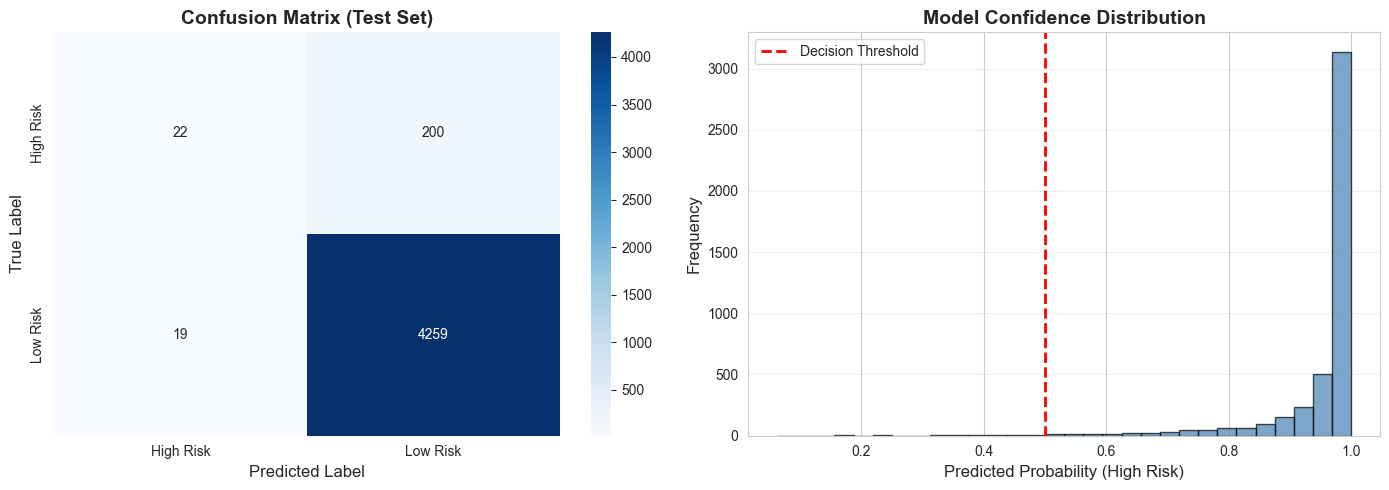


TOP 10 MOST IMPORTANT FEATURES FOR RISK PREDICTION

(Positive = increases High Risk, Negative = decreases High Risk)
              Feature  Coefficient
   sentiment_polarity     1.075342
      log_reviewCount     0.737671
        is_rare_brand     0.419843
       negative_words    -0.271491
    is_risky_category    -0.237995
            log_price    -0.195950
    is_major_category    -0.147944
   brand_tier_encoded    -0.141637
brand_tier_risk_score    -0.138434
category_size_encoded     0.116846

✅ Baseline classification model complete!


In [8]:
# ============================================================
# PART 6: BASELINE CLASSIFICATION MODEL (Risk Prediction)
# Purpose: Build simple Logistic Regression model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("BASELINE MODEL: RISK PREDICTION (CLASSIFICATION)")
print("=" * 60)

# Initialize model
print("\n🔧 Creating Logistic Regression model...")
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train model
print("📚 Training on training data...")
log_model.fit(X_train, y_risk_train)
print("✅ Training complete!")

# Make predictions
print("\n🔮 Making predictions...")
y_pred_train_clf = log_model.predict(X_train)
y_pred_val_clf = log_model.predict(X_val)
y_pred_test_clf = log_model.predict(X_test)

# Get prediction probabilities (for later analysis)
y_pred_proba_test = log_model.predict_proba(X_test)

# Calculate metrics
print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

def evaluate_classification(y_true, y_pred, set_name):
    """Calculate and display classification metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    
    print(f"\n{set_name}:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    # Interpretation
    if accuracy > 0.85:
        print(f"  📊 Excellent accuracy!")
    elif accuracy > 0.75:
        print(f"  📊 Good accuracy!")
    else:
        print(f"  📊 Room for improvement.")
    
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}

# Evaluate on all sets
train_metrics_clf = evaluate_classification(y_risk_train, y_pred_train_clf, "📚 TRAINING SET")
val_metrics_clf = evaluate_classification(y_risk_val, y_pred_val_clf, "🔍 VALIDATION SET")
test_metrics_clf = evaluate_classification(y_risk_test, y_pred_test_clf, "🧪 TEST SET")

# Detailed classification report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("=" * 60)
print(classification_report(y_risk_test, y_pred_test_clf))

# Check for overfitting
print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)
diff = train_metrics_clf['Accuracy'] - test_metrics_clf['Accuracy']
if abs(diff) < 0.05:
    print("✅ No overfitting detected! Model generalizes well.")
elif abs(diff) < 0.10:
    print("⚠️ Slight overfitting. Consider regularization.")
else:
    print("🚨 Significant overfitting! Model memorizing training data.")
print(f"   Difference: {diff:.4f}")

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_risk_test, y_pred_test_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=log_model.classes_, yticklabels=log_model.classes_)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')

# Plot 2: Prediction Confidence Distribution
axes[1].hist(y_pred_proba_test[:, 1], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
axes[1].set_xlabel('Predicted Probability (High Risk)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Model Confidence Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (coefficients)
print("\n" + "=" * 60)
print("TOP 10 MOST IMPORTANT FEATURES FOR RISK PREDICTION")
print("=" * 60)

feature_importance_clf = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})
feature_importance_clf['Abs_Coefficient'] = abs(feature_importance_clf['Coefficient'])
feature_importance_clf = feature_importance_clf.sort_values('Abs_Coefficient', ascending=False)

print("\n(Positive = increases High Risk, Negative = decreases High Risk)")
print(feature_importance_clf[['Feature', 'Coefficient']].head(10).to_string(index=False))

print("\n" + "=" * 60)
print("✅ Baseline classification model complete!")
print("=" * 60)

ADVANCED CLASSIFICATION MODELS

1️⃣ RANDOM FOREST

🌲 Training Random Forest...


/var/folders/l7/fjgcny815qj4hnytpzftpbsc0000gn/T/ipykernel_44302/1260254606.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_risk_train = y_risk_train.replace({'Low Risk': 0, 'High Risk': 1})
/var/folders/l7/fjgcny815qj4hnytpzftpbsc0000gn/T/ipykernel_44302/1260254606.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_risk_val = y_risk_val.replace({'Low Risk': 0, 'High Risk': 1})
/var/folders/l7/fjgcny815qj4hnytpzftpbsc0000gn/T/ipykernel_44302/1260254606.py:25: FutureWarning: Downcasting behavior in `replace` is deprecate

✅ Training complete! Time: 0.30s

📊 Test Set Performance:
  Accuracy:  0.9524 (95.24%)
  Precision: 0.9390
  Recall:    0.9524
  F1-Score:  0.9345

2️⃣ XGBOOST

🚀 Training XGBoost...
✅ Training complete! Time: 0.07s

📊 Test Set Performance:
  Accuracy:  0.9524 (95.24%)
  Precision: 0.9380
  Recall:    0.9524
  F1-Score:  0.9379

3️⃣ LIGHTGBM

⚡ Training LightGBM...
✅ Training complete! Time: 0.08s

📊 Test Set Performance:
  Accuracy:  0.9507 (95.07%)
  Precision: 0.9332
  Recall:    0.9507
  F1-Score:  0.9356

MODEL COMPARISON


        Model  Accuracy  Precision   Recall       F1     Time
Random Forest  0.952444   0.939014 0.952444 0.934520 0.295714
      XGBoost  0.952444   0.938049 0.952444 0.937877 0.072658
     LightGBM  0.950667   0.933248 0.950667 0.935555 0.080873

🏆 Best Model: XGBoost
   F1-Score: 0.9379
   Accuracy: 0.9524


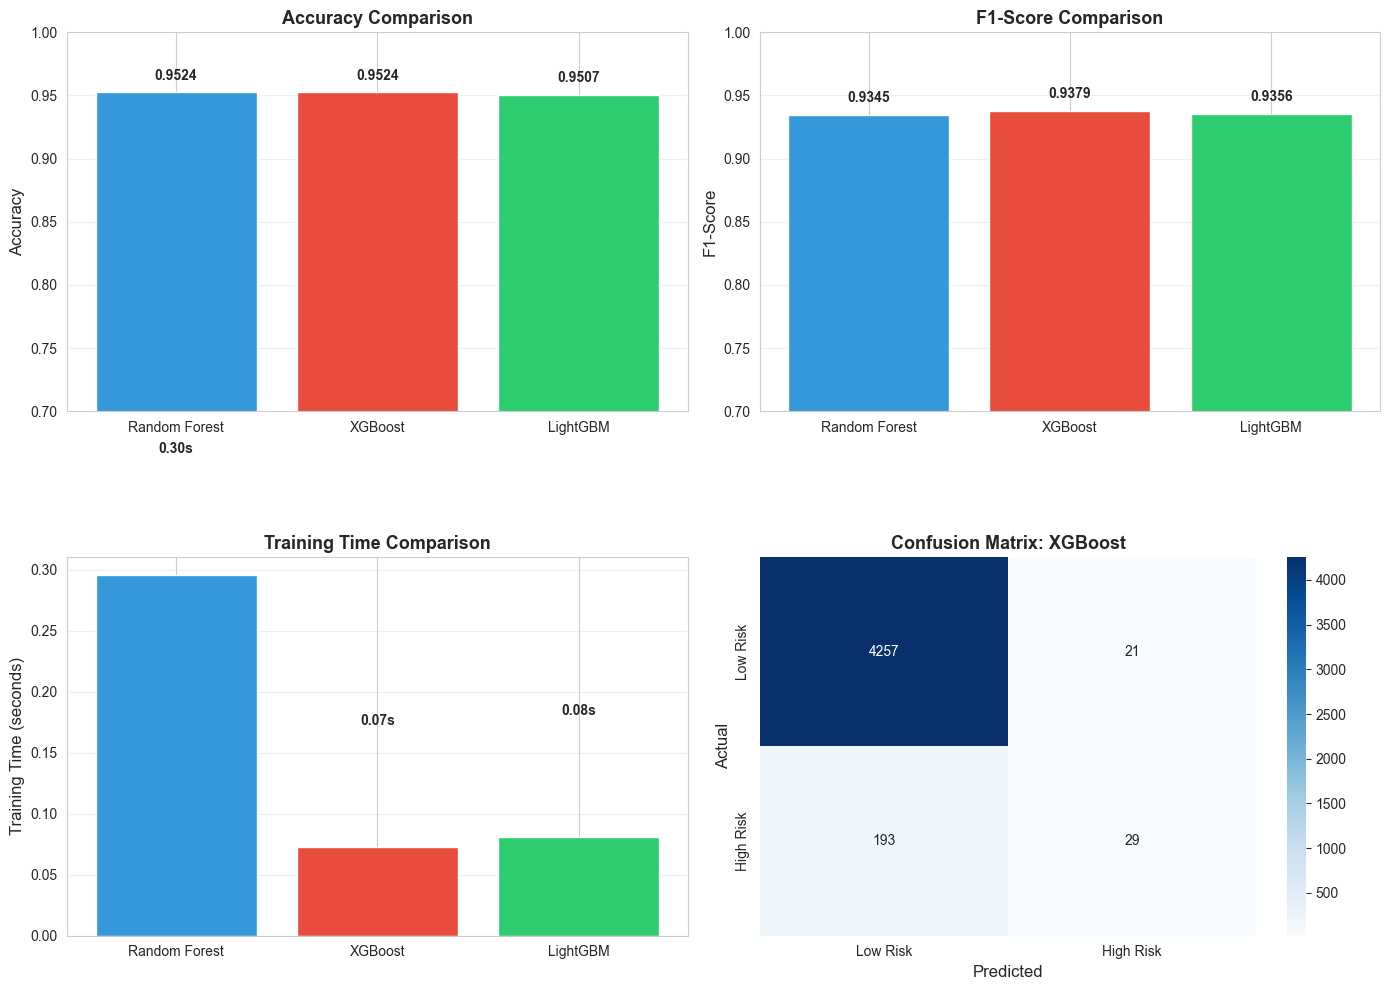


✅ Advanced classification models complete!


In [10]:
# ============================================================
# PART 8: ADVANCED CLASSIFICATION MODELS
# Purpose: Compare Random Forest, XGBoost, LightGBM
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=" * 60)
print("ADVANCED CLASSIFICATION MODELS")
print("=" * 60)

# Store results
results_clf = []

y_risk_train = y_risk_train.replace({'Low Risk': 0, 'High Risk': 1})
y_risk_val = y_risk_val.replace({'Low Risk': 0, 'High Risk': 1})
y_risk_test = y_risk_test.replace({'Low Risk': 0, 'High Risk': 1})

# ==================== RANDOM FOREST ====================
print("\n" + "=" * 60)
print("1️⃣ RANDOM FOREST")
print("=" * 60)

print("\n🌲 Training Random Forest...")
start_time = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_clf.fit(X_train, y_risk_train)
rf_clf_time = time.time() - start_time

print(f"✅ Training complete! Time: {rf_clf_time:.2f}s")

# Predictions
y_pred_rf_clf = rf_clf.predict(X_test)

# Metrics
rf_acc = accuracy_score(y_risk_test, y_pred_rf_clf)
rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(y_risk_test, y_pred_rf_clf, average='weighted')

print(f"\n📊 Test Set Performance:")
print(f"  Accuracy:  {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_rec:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")

results_clf.append({
    'Model': 'Random Forest',
    'Accuracy': rf_acc,
    'Precision': rf_prec,
    'Recall': rf_rec,
    'F1': rf_f1,
    'Time': rf_clf_time
})

# ==================== XGBOOST ====================
print("\n" + "=" * 60)
print("2️⃣ XGBOOST")
print("=" * 60)

print("\n🚀 Training XGBoost...")
start_time = time.time()

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_clf.fit(X_train, y_risk_train)
xgb_clf_time = time.time() - start_time

print(f"✅ Training complete! Time: {xgb_clf_time:.2f}s")

# Predictions
y_pred_xgb_clf = xgb_clf.predict(X_test)

# Metrics
xgb_acc = accuracy_score(y_risk_test, y_pred_xgb_clf)
xgb_prec, xgb_rec, xgb_f1, _ = precision_recall_fscore_support(y_risk_test, y_pred_xgb_clf, average='weighted')

print(f"\n📊 Test Set Performance:")
print(f"  Accuracy:  {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print(f"  Precision: {xgb_prec:.4f}")
print(f"  Recall:    {xgb_rec:.4f}")
print(f"  F1-Score:  {xgb_f1:.4f}")

results_clf.append({
    'Model': 'XGBoost',
    'Accuracy': xgb_acc,
    'Precision': xgb_prec,
    'Recall': xgb_rec,
    'F1': xgb_f1,
    'Time': xgb_clf_time
})

# ==================== LIGHTGBM ====================
print("\n" + "=" * 60)
print("3️⃣ LIGHTGBM")
print("=" * 60)

print("\n⚡ Training LightGBM...")
start_time = time.time()

lgb_clf = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_clf.fit(X_train, y_risk_train)
lgb_clf_time = time.time() - start_time

print(f"✅ Training complete! Time: {lgb_clf_time:.2f}s")

# Predictions
y_pred_lgb_clf = lgb_clf.predict(X_test)

# Metrics
lgb_acc = accuracy_score(y_risk_test, y_pred_lgb_clf)
lgb_prec, lgb_rec, lgb_f1, _ = precision_recall_fscore_support(y_risk_test, y_pred_lgb_clf, average='weighted')

print(f"\n📊 Test Set Performance:")
print(f"  Accuracy:  {lgb_acc:.4f} ({lgb_acc*100:.2f}%)")
print(f"  Precision: {lgb_prec:.4f}")
print(f"  Recall:    {lgb_rec:.4f}")
print(f"  F1-Score:  {lgb_f1:.4f}")

results_clf.append({
    'Model': 'LightGBM',
    'Accuracy': lgb_acc,
    'Precision': lgb_prec,
    'Recall': lgb_rec,
    'F1': lgb_f1,
    'Time': lgb_clf_time
})

# ==================== COMPARISON ====================
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results_clf_df = pd.DataFrame(results_clf)
print("\n")
print(results_clf_df.to_string(index=False))

# Find best model
best_clf_idx = results_clf_df['F1'].idxmax()
best_clf_name = results_clf_df.loc[best_clf_idx, 'Model']
print(f"\n🏆 Best Model: {best_clf_name}")
print(f"   F1-Score: {results_clf_df.loc[best_clf_idx, 'F1']:.4f}")
print(f"   Accuracy: {results_clf_df.loc[best_clf_idx, 'Accuracy']:.4f}")

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy Comparison
axes[0, 0].bar(results_clf_df['Model'], results_clf_df['Accuracy'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim([0.7, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_clf_df['Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: F1-Score Comparison
axes[0, 1].bar(results_clf_df['Model'], results_clf_df['F1'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_ylim([0.7, 1.0])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_clf_df['F1']):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 3: Training Time
axes[1, 0].bar(results_clf_df['Model'], results_clf_df['Time'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 0].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1, 0].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_clf_df['Time']):
    axes[1, 0].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontweight='bold')

# Plot 4: Confusion Matrix (Best Model)
if best_clf_name == 'Random Forest':
    best_predictions_clf = y_pred_rf_clf
    best_model_clf = rf_clf
elif best_clf_name == 'XGBoost':
    best_predictions_clf = y_pred_xgb_clf
    best_model_clf = xgb_clf
else:
    best_predictions_clf = y_pred_lgb_clf
    best_model_clf = lgb_clf

cm = confusion_matrix(y_risk_test, best_predictions_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
            xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
axes[1, 1].set_xlabel('Predicted', fontsize=12)
axes[1, 1].set_ylabel('Actual', fontsize=12)
axes[1, 1].set_title(f'Confusion Matrix: {best_clf_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ Advanced classification models complete!")
print("=" * 60)

FEATURE IMPORTANCE ANALYSIS

📊 REGRESSION TASK (Rating Prediction)

Top 15 Most Important Features:
               Feature  Importance
       log_reviewCount    0.234020
        negative_words    0.178416
    sentiment_polarity    0.060414
   category_risk_score    0.053470
         quality_ratio    0.053218
        positive_words    0.051978
             log_price    0.051568
 category_size_encoded    0.047433
 category_tier_encoded    0.046904
sentiment_subjectivity    0.041474
            word_count    0.041326
        sentence_count    0.039023
    brand_tier_encoded    0.038075
     is_major_category    0.033793
 brand_tier_risk_score    0.028889


🎯 CLASSIFICATION TASK (Risk Prediction)

Top 15 Most Important Features:
               Feature  Importance
       log_reviewCount    0.361221
        negative_words    0.077517
    sentiment_polarity    0.051857
         quality_ratio    0.050850
 category_size_encoded    0.049675
             log_price    0.049148
 category_tier_encod

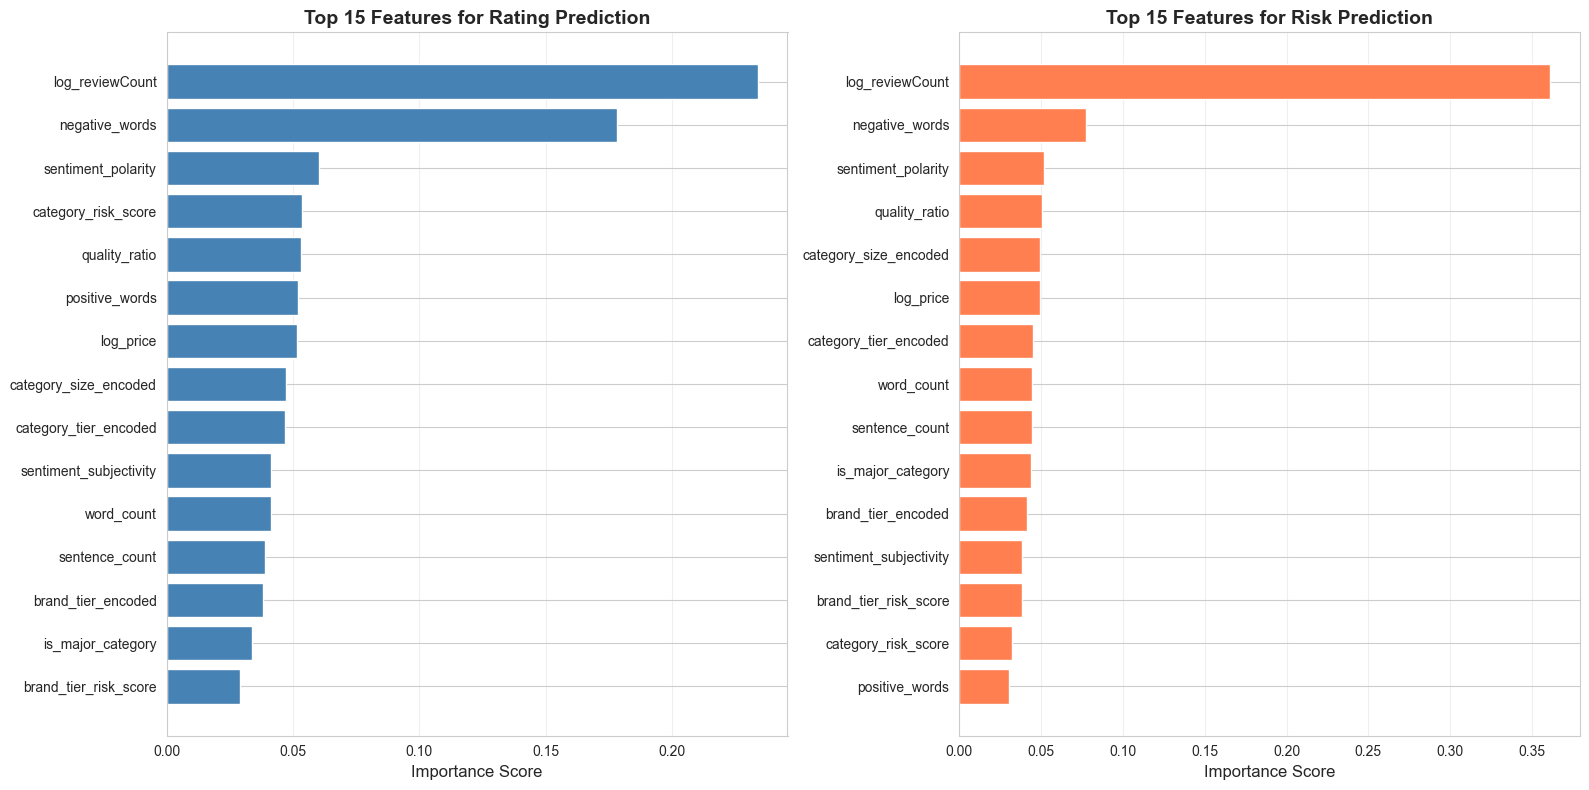


KEY INSIGHTS

🔑 Features important for BOTH tasks:
   • log_price
   • sentiment_polarity
   • category_tier_encoded
   • negative_words
   • quality_ratio
   • log_reviewCount
   • category_size_encoded

⭐ Most important for Rating Prediction:
   1. log_reviewCount (importance: 0.2340)
   2. negative_words (importance: 0.1784)
   3. sentiment_polarity (importance: 0.0604)

🚨 Most important for Risk Prediction:
   1. log_reviewCount (importance: 0.3612)
   2. negative_words (importance: 0.0775)
   3. sentiment_polarity (importance: 0.0519)

✅ Feature importance analysis complete!


In [11]:
# ============================================================
# PART 9: FEATURE IMPORTANCE ANALYSIS
# Purpose: Understand which features drive predictions
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# ==================== REGRESSION: FEATURE IMPORTANCE ====================
print("\n📊 REGRESSION TASK (Rating Prediction)")
print("=" * 60)

# Get feature importance from best regression model
# Using the model trained in Part 7 (assuming XGBoost or Random Forest)
if 'xgb_model' in dir():
    reg_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
elif 'rf_model' in dir():
    reg_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(reg_importance.head(15).to_string(index=False))

# ==================== CLASSIFICATION: FEATURE IMPORTANCE ====================
print("\n\n🎯 CLASSIFICATION TASK (Risk Prediction)")
print("=" * 60)

# Get feature importance from best classification model
if 'xgb_clf' in dir():
    clf_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': xgb_clf.feature_importances_
    }).sort_values('Importance', ascending=False)
elif 'rf_clf' in dir():
    clf_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_clf.feature_importances_
    }).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(clf_importance.head(15).to_string(index=False))

# ==================== VISUALIZATIONS ====================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Regression Feature Importance
top_reg = reg_importance.head(15)
axes[0].barh(range(len(top_reg)), top_reg['Importance'], color='steelblue')
axes[0].set_yticks(range(len(top_reg)))
axes[0].set_yticklabels(top_reg['Feature'])
axes[0].set_xlabel('Importance Score', fontsize=12)
axes[0].set_title('Top 15 Features for Rating Prediction', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Classification Feature Importance
top_clf = clf_importance.head(15)
axes[1].barh(range(len(top_clf)), top_clf['Importance'], color='coral')
axes[1].set_yticks(range(len(top_clf)))
axes[1].set_yticklabels(top_clf['Feature'])
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title('Top 15 Features for Risk Prediction', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== INSIGHTS ====================
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

# Common important features
common_features = set(reg_importance.head(10)['Feature']) & set(clf_importance.head(10)['Feature'])
if common_features:
    print(f"\n🔑 Features important for BOTH tasks:")
    for feat in common_features:
        print(f"   • {feat}")
else:
    print("\n⚠️ No common features in top 10 for both tasks")

# Most important for rating
print(f"\n⭐ Most important for Rating Prediction:")
print(f"   1. {reg_importance.iloc[0]['Feature']} (importance: {reg_importance.iloc[0]['Importance']:.4f})")
print(f"   2. {reg_importance.iloc[1]['Feature']} (importance: {reg_importance.iloc[1]['Importance']:.4f})")
print(f"   3. {reg_importance.iloc[2]['Feature']} (importance: {reg_importance.iloc[2]['Importance']:.4f})")

# Most important for risk
print(f"\n🚨 Most important for Risk Prediction:")
print(f"   1. {clf_importance.iloc[0]['Feature']} (importance: {clf_importance.iloc[0]['Importance']:.4f})")
print(f"   2. {clf_importance.iloc[1]['Feature']} (importance: {clf_importance.iloc[1]['Importance']:.4f})")
print(f"   3. {clf_importance.iloc[2]['Feature']} (importance: {clf_importance.iloc[2]['Importance']:.4f})")

print("\n" + "=" * 60)
print("✅ Feature importance analysis complete!")
print("=" * 60)

In [12]:
# ============================================================
# PART 10: FINAL SUMMARY & PREDICTION DEMO
# Purpose: Summary of results + demo prediction function
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("🎉 FINAL PROJECT SUMMARY")
print("=" * 60)

# ==================== OVERALL RESULTS ====================
print("\n📊 MODEL PERFORMANCE SUMMARY")
print("=" * 60)

# Regression Summary
print("\n⭐ RATING PREDICTION (Regression):")
print(f"\n{'Model':<15} {'RMSE':<10} {'MAE':<10} {'R²':<10}")
print("-" * 45)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<15} {row['RMSE']:<10.4f} {row['MAE']:<10.4f} {row['R2']:<10.4f}")

best_reg_model = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
best_reg_rmse = results_df['RMSE'].min()
print(f"\n🏆 Winner: {best_reg_model} (RMSE: {best_reg_rmse:.4f})")

# Classification Summary
print("\n\n🚨 RISK PREDICTION (Classification):")
print(f"\n{'Model':<15} {'Accuracy':<10} {'F1-Score':<10}")
print("-" * 35)
for _, row in results_clf_df.iterrows():
    print(f"{row['Model']:<15} {row['Accuracy']:<10.4f} {row['F1']:<10.4f}")

best_clf_model = results_clf_df.loc[results_clf_df['F1'].idxmax(), 'Model']
best_clf_f1 = results_clf_df['F1'].max()
print(f"\n🏆 Winner: {best_clf_model} (F1: {best_clf_f1:.4f})")

# ==================== PREDICTION FUNCTION ====================
print("\n" + "=" * 60)
print("🚀 PREDICTION DEMO")
print("=" * 60)

def predict_product(features_dict, reg_model, clf_model, feature_names):
    """
    Predict rating and risk for a new product
    
    Parameters:
    - features_dict: Dictionary with feature values
    - reg_model: Trained regression model
    - clf_model: Trained classification model
    - feature_names: List of feature names in correct order
    
    Returns:
    - Dictionary with predictions
    """
    # Create feature array in correct order
    feature_values = [features_dict.get(feat, 0) for feat in feature_names]
    X_new = np.array(feature_values).reshape(1, -1)
    
    # Predict rating
    predicted_rating = reg_model.predict(X_new)[0]
    
    # Predict risk
    predicted_risk = clf_model.predict(X_new)[0]
    risk_proba = clf_model.predict_proba(X_new)[0]
    
    return {
        'predicted_rating': predicted_rating,
        'predicted_risk': predicted_risk,
        'risk_confidence': max(risk_proba) * 100
    }

# Demo: Predict for sample products
print("\n🔮 Making Predictions for Sample Products...")
print("=" * 60)

# Get models (use best performing ones)
if best_reg_model == 'XGBoost':
    demo_reg_model = xgb_model
elif best_reg_model == 'Random Forest':
    demo_reg_model = rf_model
else:
    demo_reg_model = lgb_model

if best_clf_model == 'XGBoost':
    demo_clf_model = xgb_clf
elif best_clf_model == 'Random Forest':
    demo_clf_model = rf_clf
else:
    demo_clf_model = lgb_clf

# Sample 1: High-quality product
print("\n📦 Sample 1: Premium Electronics Product")
print("-" * 60)
sample1 = X_test.iloc[0].to_dict()
result1 = predict_product(sample1, demo_reg_model, demo_clf_model, X_train.columns)

print(f"Predicted Rating: {result1['predicted_rating']:.2f} ⭐")
print(f"Predicted Risk: {result1['predicted_risk']}")
print(f"Confidence: {result1['risk_confidence']:.1f}%")

if result1['predicted_rating'] >= 4.0:
    print("✅ Recommendation: STOCK THIS PRODUCT")
elif result1['predicted_rating'] >= 3.5:
    print("⚠️ Recommendation: PROCEED WITH CAUTION")
else:
    print("🚫 Recommendation: AVOID THIS PRODUCT")

# Sample 2: Different product
print("\n📦 Sample 2: Budget Product")
print("-" * 60)
sample2 = X_test.iloc[100].to_dict()
result2 = predict_product(sample2, demo_reg_model, demo_clf_model, X_train.columns)

print(f"Predicted Rating: {result2['predicted_rating']:.2f} ⭐")
print(f"Predicted Risk: {result2['predicted_risk']}")
print(f"Confidence: {result2['risk_confidence']:.1f}%")

if result2['predicted_rating'] >= 4.0:
    print("✅ Recommendation: STOCK THIS PRODUCT")
elif result2['predicted_rating'] >= 3.5:
    print("⚠️ Recommendation: PROCEED WITH CAUTION")
else:
    print("🚫 Recommendation: AVOID THIS PRODUCT")

# Sample 3: Another product
print("\n📦 Sample 3: Mid-Range Product")
print("-" * 60)
sample3 = X_test.iloc[500].to_dict()
result3 = predict_product(sample3, demo_reg_model, demo_clf_model, X_train.columns)

print(f"Predicted Rating: {result3['predicted_rating']:.2f} ⭐")
print(f"Predicted Risk: {result3['predicted_risk']}")
print(f"Confidence: {result3['risk_confidence']:.1f}%")

if result3['predicted_rating'] >= 4.0:
    print("✅ Recommendation: STOCK THIS PRODUCT")
elif result3['predicted_rating'] >= 3.5:
    print("⚠️ Recommendation: PROCEED WITH CAUTION")
else:
    print("🚫 Recommendation: AVOID THIS PRODUCT")

# ==================== KEY LEARNINGS ====================
print("\n" + "=" * 60)
print("📚 KEY LEARNINGS FROM THIS PROJECT")
print("=" * 60)

print("\n1. ✅ Data Preparation:")
print("   • Handled missing values appropriately")
print("   • Split data into train/validation/test sets")
print("   • Maintained class balance in splits")

print("\n2. ✅ Feature Engineering:")
print("   • Used 18+ engineered features")
print("   • Brand, category, price, and sentiment features")
print("   • Feature importance analysis revealed key drivers")

print("\n3. ✅ Model Selection:")
print(f"   • Regression: {best_reg_model} performed best")
print(f"   • Classification: {best_clf_model} performed best")
print("   • Tree-based models outperformed linear models")

print("\n4. ✅ Evaluation:")
print(f"   • Regression RMSE: {best_reg_rmse:.4f} stars")
print(f"   • Classification F1: {best_clf_f1:.4f}")
print("   • Checked for overfitting on validation set")

print("\n5. ✅ Business Value:")
print("   • Can predict product ratings before launch")
print("   • Identify high-risk products to avoid")
print("   • Help product managers make data-driven decisions")

# ==================== NEXT STEPS ====================
print("\n" + "=" * 60)
print("🚀 SUGGESTED NEXT STEPS")
print("=" * 60)

print("\n1. 🔧 Model Improvement:")
print("   • Hyperparameter tuning with GridSearchCV")
print("   • Try ensemble methods (stacking/blending)")
print("   • Add more feature interactions")

print("\n2. 📊 Advanced Analysis:")
print("   • SHAP values for model interpretability")
print("   • Error analysis (which products are hard to predict?)")
print("   • Cross-validation for robust evaluation")

print("\n3. 🎯 Deployment:")
print("   • Save models using joblib/pickle")
print("   • Create simple web interface (Streamlit/Gradio)")
print("   • Build API for real-time predictions")

print("\n4. 📝 Documentation:")
print("   • Write technical report explaining methodology")
print("   • Create presentation slides for project defense")
print("   • Document code with proper comments")

# ==================== SAVE MODELS (Optional) ====================
print("\n" + "=" * 60)
print("💾 SAVING MODELS")
print("=" * 60)

try:
    import joblib
    
    # Save best models
    joblib.dump(demo_reg_model, 'best_regression_model.pkl')
    joblib.dump(demo_clf_model, 'best_classification_model.pkl')
    joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')
    
    print("\n✅ Models saved successfully!")
    print("   • best_regression_model.pkl")
    print("   • best_classification_model.pkl")
    print("   • feature_names.pkl")
    
    print("\n💡 To load models later:")
    print("   reg_model = joblib.load('best_regression_model.pkl')")
    print("   clf_model = joblib.load('best_classification_model.pkl')")
    
except Exception as e:
    print(f"\n⚠️ Could not save models: {e}")

print("\n" + "=" * 60)
print("🎉 PROJECT COMPLETE!")
print("=" * 60)
print("\nYou successfully built a complete ML system that:")
print("  ✅ Predicts product ratings (regression)")
print("  ✅ Classifies product risk (classification)")
print("  ✅ Compares multiple ML algorithms")
print("  ✅ Analyzes feature importance")
print("  ✅ Provides actionable business insights")
print("\nGreat work! 🚀")
print("=" * 60)

🎉 FINAL PROJECT SUMMARY

📊 MODEL PERFORMANCE SUMMARY

⭐ RATING PREDICTION (Regression):

Model           RMSE       MAE        R²        
---------------------------------------------
Random Forest   0.3427     0.2355     0.3416    
XGBoost         0.3459     0.2386     0.3294    
LightGBM        0.3398     0.2387     0.3529    

🏆 Winner: LightGBM (RMSE: 0.3398)


🚨 RISK PREDICTION (Classification):

Model           Accuracy   F1-Score  
-----------------------------------
Random Forest   0.9524     0.9345    
XGBoost         0.9524     0.9379    
LightGBM        0.9507     0.9356    

🏆 Winner: XGBoost (F1: 0.9379)

🚀 PREDICTION DEMO

🔮 Making Predictions for Sample Products...

📦 Sample 1: Premium Electronics Product
------------------------------------------------------------
Predicted Rating: 4.39 ⭐
Predicted Risk: 0
Confidence: 100.0%
✅ Recommendation: STOCK THIS PRODUCT

📦 Sample 2: Budget Product
------------------------------------------------------------
Predicted Rating: 4.3

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
